In [1]:
pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn jupyter fastapi uvicorn joblib


  Using cached fastapi-0.136.0-py3-none-any.whl.metadata (28 kB)
  Using cached uvicorn-0.45.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached starlette-1.0.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached fastapi-0.136.0-py3-none-any.whl (117 kB)
Using cached uvicorn-0.45.0-py3-none-any.whl (69 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached starlette-1.0.0-py3-none-any.whl (72 kB)

   -------- -------------------------------  2/10 [lark]
   -------- -------------------------------  2/10 [lark]
   -------- -------------------------------  2/10 [lark]
   -------- -------------------------------  2/10 [lark]
   -------------------- -------------------  5/10 [uvicorn]
   -------------------- -------------------  5/10 [uvicorn]
   ------------------------ ---------------  6/10 [starlette]
   ---------------------------- -----------  7/10 [rfc3987-syntax]
   --------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/train.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (614, 13)

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nLoan Status distribution:")
print(df['Loan_Status'].value_counts())

Shape: (614, 13)

Column names: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Loan Status distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


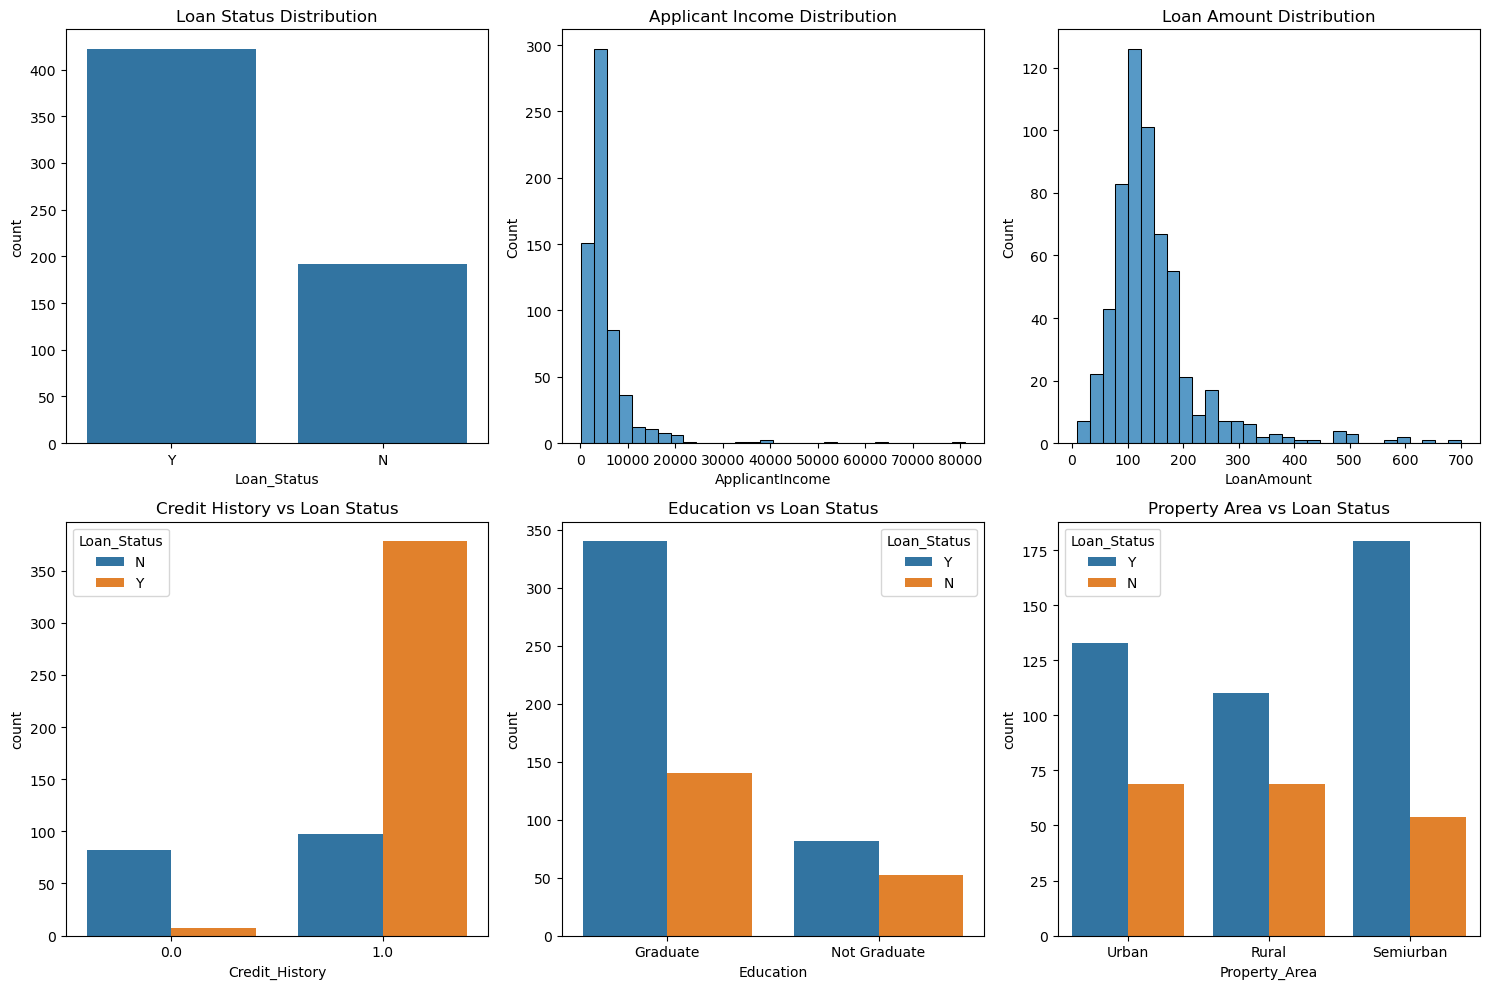

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Loan Status distribution
sns.countplot(x='Loan_Status', data=df, ax=axes[0,0])
axes[0,0].set_title('Loan Status Distribution')

# Applicant Income distribution
sns.histplot(df['ApplicantIncome'], bins=30, ax=axes[0,1])
axes[0,1].set_title('Applicant Income Distribution')

# Loan Amount distribution
sns.histplot(df['LoanAmount'].dropna(), bins=30, ax=axes[0,2])
axes[0,2].set_title('Loan Amount Distribution')

# Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, ax=axes[1,0])
axes[1,0].set_title('Credit History vs Loan Status')

# Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df, ax=axes[1,1])
axes[1,1].set_title('Education vs Loan Status')

# Property Area vs Loan Status
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=axes[1,2])
axes[1,2].set_title('Property Area vs Loan Status')

plt.tight_layout()
plt.show()

In [6]:
# Fill missing values (modern pandas syntax)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Verify no missing values remain
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [8]:
# Log transform to fix skewness
df['ApplicantIncome'] = np.log(df['ApplicantIncome'])
df['CoapplicantIncome'] = df['CoapplicantIncome'].apply(lambda x: np.log(x) if x > 0 else 0)
df['LoanAmount'] = np.log(df['LoanAmount'])

# Encode categorical columns into numbers
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# One-hot encode Property_Area (3 categories)
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

print("Columns after encoding:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Columns after encoding:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban']

First 3 rows:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,8.674026,0.00000,4.852030,360.0,1.0,1,False,True
1,1,1,1,1,0,8.430109,7.31854,4.852030,360.0,1.0,0,False,False
2,1,1,0,1,1,8.006368,0.00000,4.189655,360.0,1.0,1,False,True


In [9]:
# Convert boolean columns to integers
df['Property_Area_Semiurban'] = df['Property_Area_Semiurban'].astype(int)
df['Property_Area_Urban'] = df['Property_Area_Urban'].astype(int)

print("Done! Final shape:", df.shape)
df.head(3)

Done! Final shape: (614, 13)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,8.674026,0.00000,4.852030,360.0,1.0,1,0,1
1,1,1,1,1,0,8.430109,7.31854,4.852030,360.0,1.0,0,0,0
2,1,1,0,1,1,8.006368,0.00000,4.189655,360.0,1.0,1,0,1


In [10]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Approved (1): {(y_train == 1).sum()}")
print(f"  Rejected (0): {(y_train == 0).sum()}")

print("\nAfter SMOTE:")
print(f"  Approved (1): {(y_train_sm == 1).sum()}")
print(f"  Rejected (0): {(y_train_sm == 0).sum()}")

Before SMOTE:
  Approved (1): 337
  Rejected (0): 154

After SMOTE:
  Approved (1): 337
  Rejected (0): 337


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns

# Train Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

# Evaluate both on test set
for name, model in [("Logistic Regression", lr), ("Random Forest", rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        38
           1       0.87      0.87      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.79      0.79       123
weighted avg       0.82      0.82      0.82       123

ROC-AUC: 0.8774

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123

ROC-AUC: 0.8023


In [12]:
import joblib
import os

# Create model folder if it doesn't exist
os.makedirs('../model', exist_ok=True)

# Save the model
joblib.dump(lr, '../model/model.pkl')

# Save the feature names (we'll need these in the API)
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../model/features.pkl')

print("Model saved!")
print("Features:", feature_names)

Model saved!
Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area_Semiurban', 'Property_Area_Urban']
